In [ ]:
%reload_ext autoreload
%autoreload 2

#load libraries
import glob
import os
import pandas as pd
from datetime import datetime
import numpy as np
import main_funcs as mfun

import plot_funcs as pfun
import utils_funcs as utils 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pickle
import psychofit.psychofit as psy

# Get the data info
pfun.set_figure()


In [ ]:
# # Get the list to extract the files for further analysis
# animalList=  ['MAT057','MAT058', 'MAT067', 'MAT068','MAT069', #
#               'MAT038','MAT039', 'MAT045', 'MAT046','MAT066',
#               'HA011','HAT010'] #n = 15
# info = mfun.analysis(animalList=animalList)
# info.recordingList = info.recordingList[
#     (info.recordingList['performance'] > 50) &
#     (info.recordingList['twoP']) &
#     (info.recordingList['duration'] > 20)
#     ].reset_index(drop=True)
# info = mfun.update_info(info)
# print('Total Session fits the selection: ' +  str(info.recordingList.shape[0]))

### Add the recording side info to the info dataframe
# for idx, row in info.recordingList.iterrows():
#     # load the enviroment file from simaging path
#     print(row['imagingTiffFileNames'])
#     envFile = glob.glob(os.path.join(row['imagingTiffFileNames'], '*.env'))
#     env_exist = len(envFile) > 0
#     envFileName = envFile[0] if env_exist else None
#     print(envFileName)
#     a = mfun.parse_pv_env(envFileName)
#     # add the recording side to the info dataframe
#     a_columns = a.keys()
#     for col in a_columns:
#         info.recordingList.loc[idx, col] = a[col]



# #lets save the info for later use
# repo_analysis_path = r'C:/Users/Huriye/Documents/code/sideBiasLateralisation/analysis'
# pickle.dump(info, open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info.pkl'), 'wb'))

repo_analysis_path = r'C:/Users/Huriye/Documents/code/sideBiasLateralisation/analysis'
info = pickle.load(open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info.pkl'), 'rb'))
print('Total Session fits the selection: ' +  str(info.recordingList.shape[0]))

info.recordingList['recordingHemisphere'] = np.where(info.recordingList['YAxis'] < 0, 'Left', 'Right')
print(f"    Left: {len(info.recordingList[info.recordingList['recordingHemisphere'] == 'Left'])}" f"  Right: {len(info.recordingList[info.recordingList['recordingHemisphere'] == 'Right'])}")

#### Make the output per animal
# for animal in info.recordingList.animalID.unique():
#     animal_sessions = info.recordingList[info.recordingList.animalID == animal]
#     print(f"  Total sessions for {animal}: {len(animal_sessions)}")
#     left_recordings = animal_sessions[animal_sessions['YAxis'] < 0]
#     right_recordings = animal_sessions[animal_sessions['YAxis'] > 0]
#     print(f"    Left: {len(left_recordings)}" f"  Right: {len(right_recordings)}")

# # Lets exclude sessions if dffAll.pkl is not exist in the analysis path
# for ind in range(len(info.recordingList)):
#     dff_path = os.path.join(info.recordingList.analysispathname[ind],'all_neurons','imaging-dffTraceAll.pkl')
#     if not os.path.exists(dff_path):
#         print(f"Excluding session {info.recordingList.sessionName[ind]} due to missing dffAll.pkl")
#         info.recordingList.drop(index=ind, inplace=True)

# info.recordingList = info.recordingList.reset_index(drop=True)
# info.recordingList 


In [91]:
###  Calculate bias for each recording session
for ind, recordingDate in enumerate(info.recordingList.recordingDate):
    if (info.recordingList.sessionType[ind] =='SingleFullContrasts'): # TwoFullContrasts only look at single contrast sessions for now
        print(ind, info.recordingList.animalID[ind], info.recordingList.recordingDate[ind], end="\r", flush=True)
        recordingHemipshere = "left" if info.recordingList.YAxis[ind] < 0 else "right"
        pathname = info.recordingList.analysispathname[ind]
        sessionName = info.recordingList.sessionName[ind]
        rawpath = info.recordingList.path[ind]

        # ---- load csv file ----
        _, _, df = mfun.clean_session_behavior(pathname, sessionName, rawpath)

        # ---- calculate response time ----
        # RT = choiceCompleteTime - choiceStartTime
        df["responseTime"] = mfun.compute_response_time(df)

        # ---- calculate the cut off trials in the session - exclude motivation loss trials ----
        end_trial_number, end_trial_row_index = mfun.find_motivation_cutoff_trial(df, rt_col="responseTime", factor=4.0)
        if (end_trial_number is None) or (end_trial_number<150):
            # if no cutoff detected, keep all trials
            df_motiv = df.copy()
            cutoff_note = "no_cutoff"
        else:
            # "give me that trial as the end trial"
            # Usually you exclude that trial and all after it as "unmotivated".
            # So keep trials strictly BEFORE the end_trial_row_index.
            df_motiv = df.iloc[:end_trial_row_index].copy()
            cutoff_note = f"cutoff_at_trial_{end_trial_number}"
            info.recordingList.loc[ind, "end_trial_number"] = end_trial_number if end_trial_number is not None else np.nan

        # lets add Liebana et al. (2025) way of calculating side association
        side_assoc_metrics = mfun.computeSideAssociation(df_motiv) # Liebana et al. (2025) way for associton metrics

        for key, value in side_assoc_metrics.items():
            info.recordingList.loc[ind, key] = value
        info.recordingList.loc[ind, "zeroBias"] = side_assoc_metrics['p0'] - 0.5

        # lets calculate the bias for fitting left and then right with lingre
        _, _, stimulusBias = mfun.computeStimulusBias(df_motiv)
        info.recordingList.loc[ind, "stimulusBias"] = stimulusBias
        ##### plot psychometric curve
        pars, L, data, g = mfun.fit_psy_AllContrasts(df_motiv)
        #(fig, ax) = plt.subplots(figsize=(6, 5) )

        # lets plot the dat
        xx = data [0, :]
        nn = data [1, :]
        dd = data [2, :]
        plt.plot(xx, dd, 'k')
        plt.plot(np.arange(-50, 50), psy.erf_psycho_2gammas( pars, np.arange(-50, 50) ), color = 'r')
        plt.plot((-50, 50), (.5, .5), 'k:')
        plt.xlim([-55, 55])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('% contrast')
        plt.ylabel('proportion rightward')
        #print(f"Session: {sessionName}, Bias: {bias:.2f}, P(correct|left side): {p_right_left_side:.2f}, P(correct|right side): {p_right_right_side:.2f}")

        #lets add them as a new column to the info.recordingList 
        info.recordingList.loc[ind, "PsychoFitBias"] =  pars[0]*-1 #pars[0] > 0  → left bias 
                                                                  #pars[0] < 0  → right bias
        info.recordingList.loc[ind, "PsychoFitSlope"] = pars[2]
    # except Exception as e:
    #     info.recordingList.loc[ind, "PsychoFitBias"] = np.nan
    #     info.recordingList.loc[ind, "PsychoFitSlope"] = np.nan
    #     print(f">>>>>>>>>>>>>>>>>>>>>>>  Error occurred while processing {info.recordingList.sessionName[ind]}: {e}")

info.recordingList['imagingDataExtracted']=1

same_sign = ((info.recordingList['zeroBias'] > 0) & ((info.recordingList['R_minus_L_slope']) > 0)) | \
            ((info.recordingList['zeroBias'] < 0) & ((info.recordingList['R_minus_L_slope']) < 0))
info.recordingList['zeroBias_sideassoc_sameSign'] = same_sign

same_sign2 = ((info.recordingList['zeroBias'] > 0) & (info.recordingList['PsychoFitBias'] > 0)) | \
            ((info.recordingList['zeroBias'] < 0) & (info.recordingList['PsychoFitBias'] < 0))
info.recordingList['zeroBias_PsychoFitBias_sameSign'] = same_sign2

same_sign3 = ((info.recordingList['zeroBias'] > 0) & (info.recordingList['stimSensitivityBias'] > 0)) | \
            ((info.recordingList['zeroBias'] < 0) & (info.recordingList['stimSensitivityBias'] < 0))
info.recordingList['zeroBias_stimulusBias_sameSign'] = same_sign3


# # # save in analysis folder
plot_filename = os.path.join(info.figsPath, 'Psychometric_curve_AllSessions.png')
plt.savefig(plot_filename)
plt.close()


In [ ]:
### Explore different bias metrics.

sessionType = 'SingleFullContrasts'
recordingListSelected = info.recordingList[(info.recordingList['sessionType']== sessionType)] 
         
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(9, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=3, bottom=0.05, top=0.9, left=0.05, right=0.95,
                              wspace=0.3, hspace=0.3)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(6)}


ax_contrast[0].scatter(recordingListSelected['zeroBias'] ,recordingListSelected['PsychoFitBias'] )
ax_contrast[0].set_title( 'Zero Bias vs PschoFit bias')
ax_contrast[0].set_xlabel('Choice Bias')
# add line ax x=0 & y =0
ax_contrast[0].axhline(0, color='gray', linestyle='--')
ax_contrast[0].axvline(0, color='gray', linestyle='--')

ax_contrast[1].scatter(recordingListSelected['zeroBias'] ,recordingListSelected['stimSensitivity'] )
ax_contrast[1].set_title( 'Zero Bias vs stimulus sensitivity')
ax_contrast[1].set_xlabel('Choice Bias')
ax_contrast[5].axhline(0, color='gray', linestyle='--')
ax_contrast[5].axvline(0, color='gray', linestyle='--')

ax_contrast[2].scatter(recordingListSelected['PsychoFitBias'] ,recordingListSelected['stimSensitivity'] )
ax_contrast[2].set_title( 'PsychoFit Bias vs stimulus sensitivity')
ax_contrast[2].set_xlabel('PschoFit Bias')
ax_contrast[5].axhline(0, color='gray', linestyle='--')
ax_contrast[5].axvline(0, color='gray', linestyle='--')

ax_contrast[3].scatter(recordingListSelected['zeroBias'], recordingListSelected['R_minus_L_slope'])
ax_contrast[3].set_title('zeroBias vs R_minus_L_slope')
ax_contrast[3].set_xlabel('Choice Bias')
ax_contrast[3].axhline(0, color='gray', linestyle='--')
ax_contrast[3].axvline(0, color='gray', linestyle='--')

ax_contrast[4].scatter(recordingListSelected['zeroBias'], recordingListSelected['stimSensitivityBias'])
ax_contrast[4].set_title('zeroBias vs stimSensitivityBias')
ax_contrast[4].set_ylim(-10, 10)
ax_contrast[4].set_xlabel('Choice Bias')
ax_contrast[4].axhline(0, color='gray', linestyle='--')
ax_contrast[4].axvline(0, color='gray', linestyle='--')

ax_contrast[5].scatter(recordingListSelected['PsychoFitBias'], recordingListSelected['stimSensitivityBias'])
ax_contrast[5].set_title('PsychoFitBias vs stimSensitivityBias')
ax_contrast[5].set_xlabel('PsychoFitBias')
ax_contrast[5].set_ylim(-10, 10)
ax_contrast[5].axhline(0, color='gray', linestyle='--')
ax_contrast[5].axvline(0, color='gray', linestyle='--')

plot_filename = os.path.join(info.figsPath, 'BiasExploration_AllSessions.png')
plt.savefig(plot_filename)
plt.close()


In [ ]:
### Beh Plot: the values of bias etc - to explore the behavioural sessions
sessionType = 'SingleFullContrasts'
recordingListSelected = info.recordingList[(info.recordingList['sessionType']== sessionType)] 
                                            
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=2, bottom=0.05, top=0.9, left=0.05, right=0.95,
                              wspace=0.3, hspace=0.3)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(4)}


ax_contrast[1].plot(recordingListSelected['zeroBias'], label='P(Correct| Zero)')
ax_contrast[1].plot(recordingListSelected['R_minus_L_slope'], 
                    label='P(Right|Right Stimuli) - P(Right|Left Stimuli)') 
ax_contrast[1].plot(recordingListSelected['zeroBias_PsychoFitBias_sameSign']+0.5, 'o', markersize=2,
                    label='Bias and Psychometric Bias Same Sign') 
ax_contrast[1].set_title(f' PsychoBias n = {np.sum(recordingListSelected["zeroBias_PsychoFitBias_sameSign"]==False)} ; AverageAssoc n = {np.sum(recordingListSelected["zeroBias_sideassoc_sameSign"]==False)}')
#add a line at y =0
ax_contrast[1].axhline(0, color='k', linestyle='--')
ax_contrast[1].set_ylim([-0.9, 0.9]) 
ax_contrast[1].set_xlabel('Session Index')
ax_contrast[1].set_ylabel('Bias across sessions')
ax_contrast[1].legend()

sns.histplot(recordingListSelected['zeroBias'], bins=20, kde=True, ax=ax_contrast[0])
# add total number of sessions in the title
ax_contrast[0].set_title(f'Choice Bias - n={recordingListSelected.shape[0]} sessions')
ax_contrast[0].set_xlim([-1, 1])  

sns.histplot(recordingListSelected['stimSensitivity'], bins=20, kde=True, ax=ax_contrast[2])
ax_contrast[2].set_title('Stimulus Sensitivity')
ax_contrast[2].set_xlim([-10, 10])

sns.histplot(recordingListSelected['stimSensitivityBias'], bins=20, kde=True, ax=ax_contrast[3])
ax_contrast[3].set_title('Stimulus Sensitivity Bias')
ax_contrast[3].set_xlim([-40, 40])

# save with animal ID
plot_filename = os.path.join(info.figsPath, f"BiasMetricExploration_{sessionType}.png")
plt.savefig(plot_filename)
#plt.close()

print('Plot saved: ' + plot_filename)


In [ ]:
## Plot psychometric curves for selected sessions together
sessionType = 'SingleFullContrasts'
recordingListSelected = info.recordingList[(info.recordingList['sessionType']==sessionType)#& (info.recordingList['animalID']== selectedAnimal)
                                            ].reset_index(drop=True)

saveFileName = os.path.join(info.figsPath, f"{selectedAnimal}_psychometric_{sessionType}.png")

pfun.plot_combined_psychometric(
    recordingList= recordingListSelected,
    save_fileName= saveFileName,
)

In [ ]:
# All Sessions EXCITED vs INHIBITED comparison
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 15)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=1, bottom=0, top=0.45, left=0.05, right=0.95,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}

t2 = 1 # Analysis window second

infoSelected = info.recordingList#[(info.recordingList['performance'] >95)].reset_index(drop=True)

response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[0],
    title = ' Excited cells',
)

response_typeValue = 'inhibited' # 'excited', 'inhibited', 'all'
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[1],
    title = ' Inhibited cells',
)

pfun.save_figure(f'AllSessions', info.figsPath)


In [ ]:
# COMPARISON PLOT FOR SAME AND OPPOSITE SIGN ASSOCIATION - REGARDLESS OF RECORDINGS HEMISPHERE

pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 15)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=3, nrows=3, bottom=0, top=0.9, left=0.05, right=0.95,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(9)}

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'biasPsycho_bias' #'bias' #
selectedHemisphere = 'Left'
bias_sideassoc_same_signValue = True
response_typeValue = 'inhibited' # 'excited', 'inhibited', 'all'
if bias_sideassoc_same_signValue:
    subtitle_suffix = 'SameSignAssociation'
else:
    subtitle_suffix = 'OppositeSignAssociation'

leftThreshold = -1 #0.15
rightThreshold = 1# 0.15
performanceCutOff = 70
t2 = 1 # Analysis window second


###### Plot the histogram for bias
ax_contrast[0].remove()                       # remove old axis in slot 0
ax_contrast[1].remove()                       # remove old axis in slot 0
ax_contrast[0] = fig.add_subplot(gs_contrast[0, 0:2])  # span first two slots
ax_contrast[0].hist(info.recordingList[biasType]
                    [(info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                     (info.recordingList['sessionType'] == sessionType)].dropna(),
                    bins=20, color = 'black')
ax_contrast[0].set_ylabel('Number of sessions')
ax_contrast[0].set_xlabel('Bias - P(Right | 0 contrast)')
ax_contrast[0].set_title('Distribution of Bias across sessions, threshold: ' + str(rightThreshold) )
ax_contrast[0].set_xlim([-50, 50])
#ax_contrast[0].set_xlim([-0.5, 0.5])
#ax_contrast[0].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])

# get the total number of recording for 0.75 above + 0.25 below
num_high_bias = len(info.recordingList[info.recordingList[biasType] >= rightThreshold])
num_low_bias = len(info.recordingList[info.recordingList[biasType] <= leftThreshold])
print(f'Number of sessions with bias >=0.25: {num_high_bias}')  
print(f'Number of sessions with bias <=-0.25: {num_low_bias}')

##### SAME SIGN Plot the mean dF/F by contrast for low bias sessions - LEFT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] < leftThreshold) & 
                                (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['sessionType'] == sessionType) &
                                (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[3],
    title = 'Left ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +' )',
)

# Plot the mean dF/F by contrast for low bias sessions - RIGHT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] > rightThreshold) &
                                   (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                   (info.recordingList['sessionType'] == sessionType) &
                                   (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                   (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[4],
    title = 'Right ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
    align_to_hemisphere = True,
)


# Plot the mean dF/F by contrast for low bias sessions - LEFT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] <= rightThreshold) &
                                (info.recordingList[biasType] >= leftThreshold) & 
                                  (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                  (info.recordingList['sessionType'] == sessionType) &
                                  (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                  (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)


# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[5],
    title = 'Balanced ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
    align_to_hemisphere = True,
)

####### OPPOSITE SIGN 
bias_sideassoc_same_signValue = False
subtitle_suffix = 'OppositeSignAssociation'

infoSelected = info.recordingList[(info.recordingList[biasType] < leftThreshold) & 
                                (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['sessionType'] == sessionType) &
                                (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[6],
    title = 'Left ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +' )',
    align_to_hemisphere = True,
)

# Plot the mean dF/F by contrast for low bias sessions - RIGHT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] > rightThreshold) &
                                   (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                   (info.recordingList['sessionType'] == sessionType) &
                                   (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                   (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[7],
    title = 'Right ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
    align_to_hemisphere = True,
)


# Plot the mean dF/F by contrast for low bias sessions - LEFT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] <= rightThreshold) &
                                (info.recordingList[biasType] >= leftThreshold) & 
                                  (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                  (info.recordingList['sessionType'] == sessionType) &
                                  (info.recordingList['recordingHemisphere']==selectedHemisphere) &
                                  (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)


# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[8],
    title = 'Balanced ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
)

pfun.save_figure(f'{selectedAnimal}_{response_typeValue}_{biasType}_{sessionType}_{selectedHemisphere}', info.figsPath)



In [ ]:
# 4 BEH PLOTS: hemipshere vs bias association 
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 15)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=3, bottom=0, top=0.9, left=0.25, right=0.75,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(6)}

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'stimSensitivityBias' #'zeroBias' #'PsychoFitBias' #
response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
bias_sideassoc_same_signValue = None # zeroBias_sideassoc_sameSign, 
                                      # zeroBias_stimulusBias_sameSign, zeroBias_PsychoFitBias_sameSign,
ylimValues = [-0.1, 0.3]

leftThreshold =  -0.5#-3.1 #
rightThreshold =   0.5 #3.0#
performanceCutOff = 70
performanceUpperCutOff = 100

# Lets clean the info
infoSelectedAll = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
                              #  (info.recordingList['zeroBias_stimulusBias_sameSign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['performance'] >performanceCutOff) &
                                (info.recordingList['performance'] <performanceUpperCutOff)].reset_index(drop=True)

###### Plot the HISTOGRAM for bias
ax_contrast[0].remove()                       # remove old axis in slot 0
ax_contrast[1].remove()                       # remove old axis in slot 0
ax_contrast[0] = fig.add_subplot(gs_contrast[0, 0:2])  # span first two slots
ax_contrast[0].hist(infoSelectedAll[biasType].dropna(),
                    bins=20, color = 'black')
ax_contrast[0].set_ylabel('Number of sessions')
ax_contrast[0].set_xlabel('Bias')
ax_contrast[0].set_title(f'{biasType}, threshold: {rightThreshold}, n = {infoSelectedAll.shape[0]}')
if biasType == 'PsychoFitBias':
    ax_contrast[0].set_xlim([-40, 40])
elif biasType =='zeroBias':       
    ax_contrast[0].set_xlim([-0.5, 0.5])
elif biasType == 'stimSensitivityBias':
    ax_contrast[0].set_xlim([-40, 40])


#####  Plot the MEAN dF/F by contrast for low bias sessions - LEFT HEMISPHERE - left bias

selectedHemisphere = 'Left'
infoSelected = infoSelectedAll[(infoSelectedAll[biasType] < leftThreshold) &
                            (infoSelectedAll['recordingHemisphere']==selectedHemisphere)
                            ].reset_index(drop=True)
print('Number of sessions for Left Bias, Left Hemisphere: ' + str(infoSelected.shape[0]))
pfun.plotContrastBeh(infoSelected, axis=ax_contrast[2], individualSession=True)
ax_contrast[2].set_title('Left Sensory Sensitivity Bias n=' + str(infoSelected.shape[0]))

infoSelected = infoSelectedAll[(infoSelectedAll[biasType] > rightThreshold) &
                            (infoSelectedAll['recordingHemisphere']==selectedHemisphere)
                            ].reset_index(drop=True)
print('Number of sessions for Right Bias, Left Hemisphere: ' + str(infoSelected.shape[0]))
pfun.plotContrastBeh(infoSelected, axis=ax_contrast[3], individualSession=True)
ax_contrast[3].set_title('Right Sensory Sensitivity Bias n=' + str(infoSelected.shape[0]))

selectedHemisphere = 'Right'
infoSelected = infoSelectedAll[(infoSelectedAll[biasType] < leftThreshold) &
                            (infoSelectedAll['recordingHemisphere']==selectedHemisphere)
                            ].reset_index(drop=True)
print('Number of sessions for Left Bias, Right Hemisphere: ' + str(infoSelected.shape[0]))
pfun.plotContrastBeh(infoSelected, axis=ax_contrast[4], individualSession=True)
ax_contrast[4].set_title('Left Sensory Sensitivity Bias n=' + str(infoSelected.shape[0]))

infoSelected = infoSelectedAll[(infoSelectedAll[biasType] > rightThreshold) &
                            (infoSelectedAll['recordingHemisphere']==selectedHemisphere)
                            ].reset_index(drop=True)
print('Number of sessions for Right Sensory Sensitivity Bias, Right Hemisphere: ' + str(infoSelected.shape[0]))
pfun.plotContrastBeh(infoSelected, axis=ax_contrast[5], individualSession=True)
ax_contrast[5].set_title('Right Bias n=' + str(infoSelected.shape[0]))

# save the figure
pfun.save_figure(f'Behavior_Contrast_{response_typeValue}_{biasType}_{rightThreshold}_sameSign{bias_sideassoc_same_signValue}', info.figsPath)


Left Bias, Left Hemisphere: n = 0
Right Bias, Left Hemisphere: n = 18
Left Bias, Right Hemisphere: n = 0
Right Bias, Right Hemisphere: n = 24


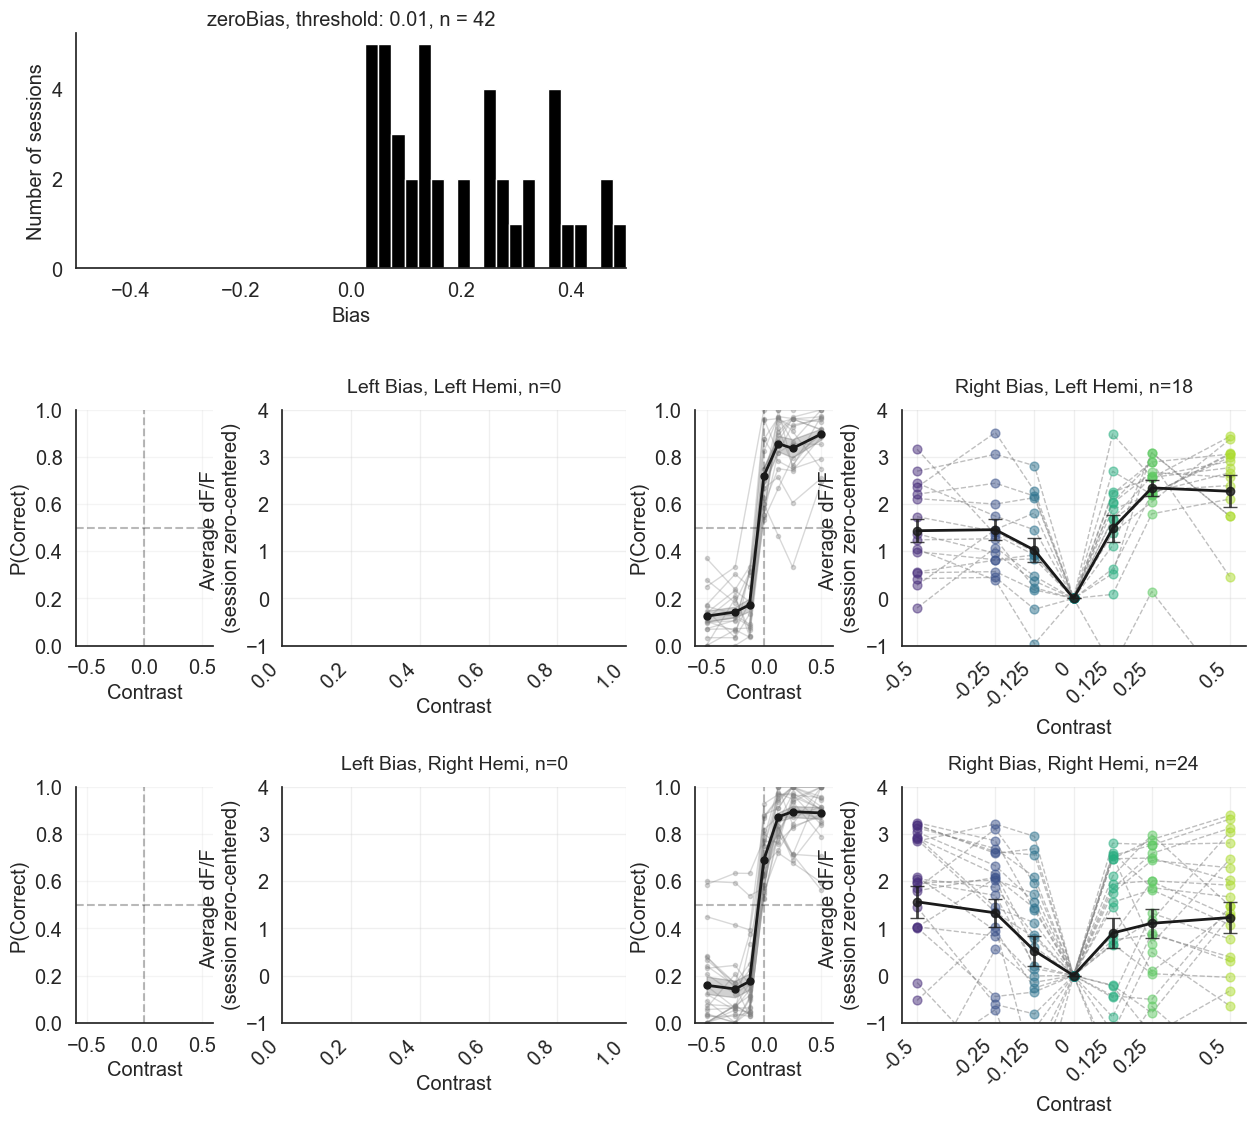

In [ ]:
# 4 NEURAL + BEH PLOTS : hemipshere vs bias association 

pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(13, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=6, nrows=3, bottom=0.05, top=0.95, left=0.05, right=0.95,
                              wspace=0.5, hspace=0.6)
ax_contrast = {
    'hist': fig.add_subplot(gs_contrast[0, 0:3]),

    'LL_beh': fig.add_subplot(gs_contrast[1, 0]),
    'LL_neuro':   fig.add_subplot(gs_contrast[1, 1:3]),
    'LR_beh': fig.add_subplot(gs_contrast[1, 3]),
    'LR_neuro':   fig.add_subplot(gs_contrast[1, 4:6]),

    'RL_beh': fig.add_subplot(gs_contrast[2, 0]),
    'RL_neuro':   fig.add_subplot(gs_contrast[2, 1:3]),
    'RR_beh': fig.add_subplot(gs_contrast[2, 3]),
    'RR_neuro':   fig.add_subplot(gs_contrast[2, 4:6]),
}

#### Parameters
# Lts run it for False and True for the same sign association
for bias_sideassoc_same_signValue in [True, False]:

    sessionType = 'SingleFullContrasts'
    biasType = 'zeroBias' #'zeroBias' #'PsychoFitBias' #
    response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
    # bias_sideassoc_same_signValue = True # zeroBias_sideassoc_sameSign, 
    #                                       # zeroBias_stimulusBias_sameSign, zeroBias_PsychoFitBias_sameSign,
    ylimValues = [-1, 4]

    leftThreshold =  -0.01#-3.1 #
    rightThreshold =   0.01 #3.0#
    performanceCutOff = 70
    performanceUpperCutOff = 100

    # Lets clean the info
    infoSelectedAll = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
                                    (info.recordingList['zeroBias_sideassoc_sameSign']== bias_sideassoc_same_signValue) &
                                    (info.recordingList['performance'] >performanceCutOff) &
                                    (info.recordingList['performance'] <performanceUpperCutOff)].reset_index(drop=True)



    ###### Plot the HISTOGRAM for bias
    ax_contrast['hist'].hist(infoSelectedAll[biasType].dropna(),
                        bins=20, color = 'black')
    ax_contrast['hist'].set_ylabel('Number of sessions')
    ax_contrast['hist'].set_xlabel('Bias')
    ax_contrast['hist'].set_title(f'{biasType}, threshold: {rightThreshold}, n = {infoSelectedAll.shape[0]}')
    if biasType == 'PsychoFitBias':
        ax_contrast['hist'].set_xlim([-40, 40])
    else:       
        ax_contrast['hist'].set_xlim([-0.5, 0.5])


    #####  Plot the MEAN dF/F by contrast for low bias sessions - LEFT HEMISPHERE - left bias
    # ---- 4 neural plots: hemisphere x bias direction ----
    plot_configs = [
        ('Left',  'Left',  leftThreshold,  '<', ax_contrast['LL_neuro'] ,ax_contrast['LL_beh']),
        ('Left',  'Right', rightThreshold, '>', ax_contrast['LR_neuro'],ax_contrast['LR_beh']),
        ('Right', 'Left',  leftThreshold,  '<', ax_contrast['RL_neuro'], ax_contrast['RL_beh']),
        ('Right', 'Right', rightThreshold, '>', ax_contrast['RR_neuro'],ax_contrast['RR_beh']),
    ]

    for hemisphere, bias_label, threshold, direction, ax , ax_psch in plot_configs:
        mask = (infoSelectedAll[biasType] < threshold) if direction == '<' \
            else (infoSelectedAll[biasType] > threshold)
        infoSelected = infoSelectedAll[
            mask & (infoSelectedAll['recordingHemisphere'] == hemisphere)
        ].reset_index(drop=True)

        print(f'{bias_label} Bias, {hemisphere} Hemisphere: n = {infoSelected.shape[0]}')

        pfun.plotContrastBeh(infoSelected, axis=ax_psch, individualSession=True)

        data_out = pfun.createMeanDffByContrastData(
            infoSelected,
            event_type='stimulus',
            response_type=response_typeValue,
            time_window=None,
            align_to_hemisphere=False,
            session_normalization='zero_center')

        pfun.plotMeanDffByContrastFromData(
            data_out, axis=ax, ylim=ylimValues,
            title=f'{bias_label} Bias, {hemisphere} Hemi, n={infoSelected.shape[0]}')

    pfun.save_figure(
        f'Neuro_Contrast_{response_typeValue}_{biasType}_{sessionType}_sameSign{bias_sideassoc_same_signValue}',
        info.figsPath)

Number of sessions for Ipsi Bias: 42
Error processing session 2025-12-09_1_MAT068: boolean index did not match indexed array along axis 2; size of axis is 231 but size of corresponding boolean axis is 253
Error processing session 2025-08-03_1_HAT010: boolean index did not match indexed array along axis 2; size of axis is 185 but size of corresponding boolean axis is 186
Number of sessions for Contra Bias: 53


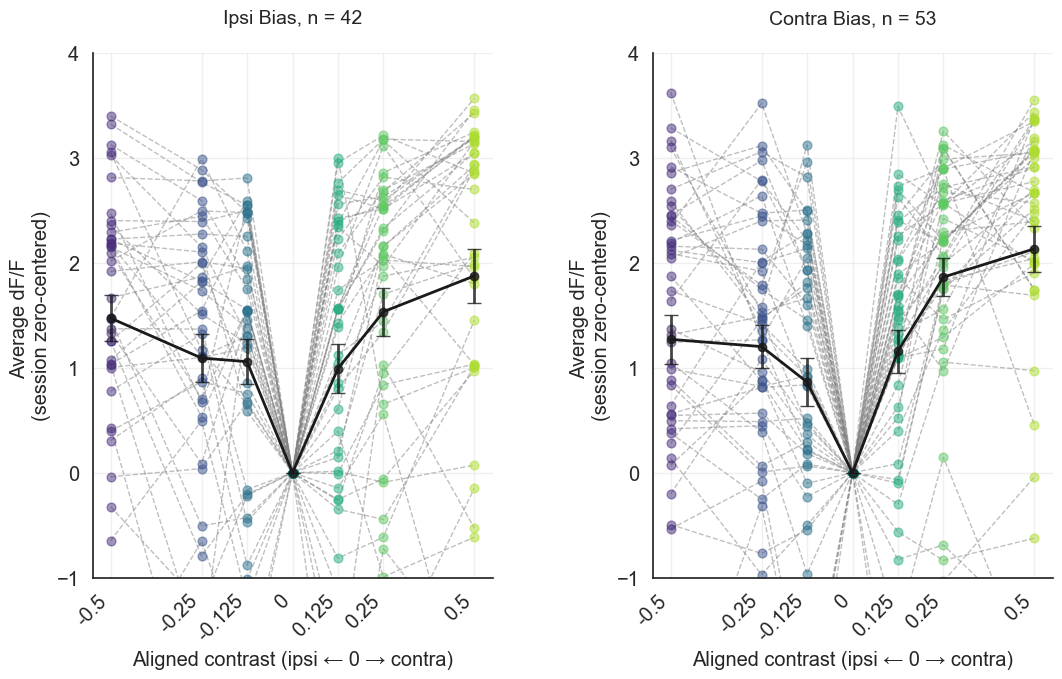

In [ ]:
### 2 NEURAL PLOTS : hemipshere merges - 2 bias plot

pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 15)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=1, bottom=0, top=0.35, left=0.05, right=0.65,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'zeroBias' #'zeroBias' #'PsychoFitBias' #
response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
bias_sideassoc_same_signValue = False # zeroBias_sideassoc_sameSign, 
                                      # zeroBias_stimulusBias_sameSign, zeroBias_PsychoFitBias_sameSign,
ylimValues = [-1, 4]

leftThreshold =  -0.01#-3.1 #
rightThreshold =   0.01 #3.0#
performanceCutOff = 70
performanceUpperCutOff = 100

# Lets clean the info
infoSelectedAll = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
                                (info.recordingList['zeroBias_sideassoc_sameSign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['performance'] >performanceCutOff) &
                                (info.recordingList['performance'] <performanceUpperCutOff)].reset_index(drop=True)


#####  Plot the mean dF/F by contrast for low bias sessions - IPSI BIAS

infoSelected = infoSelectedAll[
    (
        (
            (infoSelectedAll[biasType] < leftThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Left')
        ) |
        (
            (infoSelectedAll[biasType] > rightThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Right')
        )
    ) ].reset_index(drop=True)
print('Number of sessions for Ipsi Bias: ' + str(infoSelected.shape[0]))
data_out = pfun.createMeanDffByContrastData(
    infoSelected,
    event_type='stimulus',
    response_type=response_typeValue,
    time_window=None,
    align_to_hemisphere=True,
    session_normalization='zero_center'
)

pfun.plotMeanDffByContrastFromData(data_out,
                                   axis = ax_contrast[0], ylim = ylimValues,
                                   title = 'Ipsi Bias, n = ' + str(infoSelected.shape[0]),
                                   )

# Plot the mean dF/F by contrast for low bias sessions - CONTRA BIAS

infoSelected = infoSelectedAll[
    (
        (
            (infoSelectedAll[biasType] < leftThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Right') # Contra
        ) |
        (
            (infoSelectedAll[biasType] > rightThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Left') # Contra
        )
    )].reset_index(drop=True)
print('Number of sessions for Contra Bias: ' + str(infoSelected.shape[0]))

data_out = pfun.createMeanDffByContrastData(
    infoSelected,
    event_type='stimulus',
    response_type=response_typeValue,
    time_window=None,
    align_to_hemisphere=True,
    session_normalization='zero_center'
)

pfun.plotMeanDffByContrastFromData(data_out,
                                   axis = ax_contrast[1], ylim = ylimValues,
                                   title = 'Contra Bias, n = ' + str(infoSelected.shape[0]),
                                   )

pfun.save_figure(f'NeuroMerged_Contrast_{response_typeValue}_{biasType}_{sessionType}_sameSign{bias_sideassoc_same_signValue}', info.figsPath)



Ipsi Bias: n = 18
Error processing session 2025-12-09_1_MAT068: boolean index did not match indexed array along axis 2; size of axis is 231 but size of corresponding boolean axis is 253
Error processing session 2025-08-03_1_HAT010: boolean index did not match indexed array along axis 2; size of axis is 185 but size of corresponding boolean axis is 186
Contra Bias: n = 35


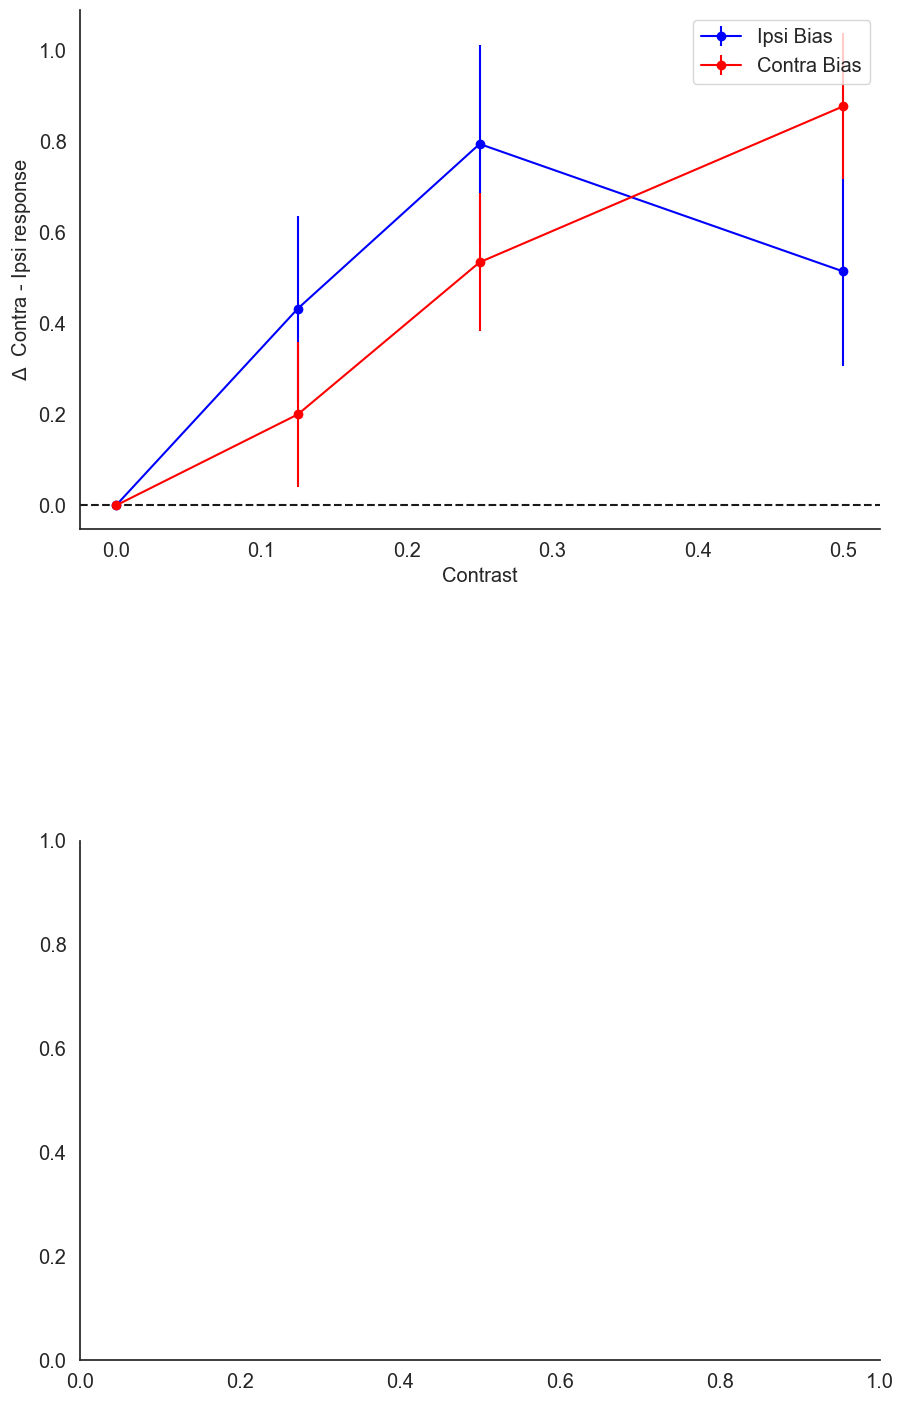

In [85]:
# Summary Line plot for hemisphere across contrast values
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 15)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=1, nrows=2, bottom=0, top=0.9, left=0.25, right=0.75,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(2)}

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'zeroBias' #'zeroBias' #'PsychoFitBias' #
response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
bias_sideassoc_same_signValue = False # zeroBias_sideassoc_sameSign, 
                                      # zeroBias_stimulusBias_sameSign, zeroBias_PsychoFitBias_sameSign,
ylimValues = [-1, 4]

leftThreshold =  -0.01#-3.1 #
rightThreshold =   0.01 #3.0#
performanceCutOff = 70
performanceUpperCutOff = 100

# Lets clean the info
infoSelectedAll = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
                                (info.recordingList['zeroBias_sideassoc_sameSign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['performance'] >performanceCutOff) &
                                (info.recordingList['performance'] <performanceUpperCutOff)].reset_index(drop=True)


ax = ax_contrast[0]

for cond, color in [ ('Ipsi Bias', 'blue'),
                     ('Contra Bias', 'red')]:
   
    if cond == 'Ipsi Bias':
       infoSelected = infoSelectedAll[
        (
            (infoSelectedAll[biasType] < leftThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Left')
        ) |
        (
            (infoSelectedAll[biasType] > rightThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Right')
        )].reset_index(drop=True)
    else:
         infoSelected = infoSelectedAll[
          (
            (infoSelectedAll[biasType] < leftThreshold ) &
            (infoSelectedAll['recordingHemisphere'] == 'Right') # Contra
          ) |
          (
            (infoSelectedAll[biasType] > rightThreshold) &
            (infoSelectedAll['recordingHemisphere'] == 'Left') # Contra
          )].reset_index(drop=True)
    print(f'{cond}: n = ' + str(infoSelected.shape[0]))
    data_out = pfun.createMeanDffByContrastData(
        infoSelected,
        event_type='stimulus',
        response_type=response_typeValue,
        time_window = None,
        align_to_hemisphere=True,
        session_normalization='zero_center')
    

    contrast_summary = pfun.contrastHemisphereDifference(data_out)

    ax.errorbar(
        contrast_summary.index,
        contrast_summary['mean'],
        yerr=contrast_summary['sem'],
        fmt='o-', color=color, label=cond)

ax.axhline(0, linestyle='--', color='k')
ax.set_xlabel('Contrast')
ax.set_ylabel('$\\Delta$  Contra - Ipsi response')
ax.legend()

pfun.save_figure(f'Neural_SummaryHemi_{response_typeValue}_{biasType}_{sessionType}_sameSign{bias_sideassoc_same_signValue}', info.figsPath)

In [ ]:
# GLM ANALYSIS 

import statsmodels.formula.api as smf

# infoSelected = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
#                                 (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'zeroBias' #'zeroBias' #'PsychoFitBias' #
response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
bias_sideassoc_same_signValue = None # zeroBias_sideassoc_sameSign, 
                                      # zeroBias_stimulusBias_sameSign, zeroBias_PsychoFitBias_sameSign,
ylimValues = [-1, 4]

leftThreshold =  -0.01#-3.1 #
rightThreshold =   0.01 #3.0#
performanceCutOff = 70
performanceUpperCutOff = 100

# Lets clean the info
infoSelectedAll = info.recordingList[(info.recordingList['sessionType'] == sessionType) &
                              #  (info.recordingList['zeroBias_stimulusBias_sameSign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['performance'] >performanceCutOff) &
                                (info.recordingList['performance'] <performanceUpperCutOff)].reset_index(drop=True)

data_out = pfun.createMeanDffByContrastData(
    infoSelectedAll,
    event_type='stimulus',
    response_type=response_typeValue,
    align_to_hemisphere=False,
    session_normalization='zero_center')

glm_df = pfun.create_glm_dataframe(data_out, info.recordingList, bias_col='zeroBias')
formula = f"mean_dff ~ contrast_c * bias_c * hemisphere * stimuluBiasIndex * performance"
model = smf.ols(formula=formula, data=glm_df).fit()
print(model.summary())

########





######
###




 
 
 MOST LIKELY OK TO DELETE : March 17


 

In [ ]:
df_cdiff = mfun.get_mean_dff_by_contrast_diff_df(info.recordingList[ (info.recordingList['bias_sideassoc_same_sign']== False)].reset_index(drop=True), event_type="stimulus", biasType=biasType)

df = df_cdiff.copy()
df["side"] = np.where(
    df["cDiff"] > 0, "Right",
    np.where(df["cDiff"] < 0, "Left", None)  # <-- None, not np.nan
)

out = (
    df.groupby(["animal", "session", "recordingDate",'bias', 'performance',"side"], as_index=False)
      .agg(mean_dff=("mean_dff", "mean"))
      .pivot_table(
          index=["animal", "session", "recordingDate", 'bias', 'performance'],
          columns="side",
          values="mean_dff",
      )
      .reset_index()
)

df = out.copy()
df['cDiff'] = df['Right'] - df['Left']

pfun.set_figure()
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=df, x='bias', y='cDiff', ax=ax, color='black')
ax.set_xlabel('Behavioral Bias \n(Proportion of Right choices at 0 contrast)')
ax.set_ylabel('Neural Lateralisation \n(Mean dF/F Right - Mean dF/F Left)')
# add stats & line
from scipy.stats import pearsonr
r, p = pearsonr(df['bias'], df['cDiff'])
#sns.regplot(data=df, x='bias', y='cDiff', ax=ax, scatter=False, color='red', line_kws={'linewidth':1})
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}')
pfun.save_figure(f'Phase4_DifferentSide_BehavioralBias_vs_NeuralLateralisation', info.figsPath)

# add only really good performance
df_highperf = df[df['performance'] >=0.85]
sns.scatterplot(data=df_highperf, x='bias', y='cDiff', ax=ax, color='darkred')
r2, p2 = pearsonr(df_highperf['bias'], df_highperf['cDiff'])
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}' + f'\n High Performance: r={r2:.2f}, p={p2:.3f}')
pfun.save_figure(f'Phase4_DifferentSide_BehavioralBias_vs_NeuralLateralisation_highPerf', info.figsPath)


In [ ]:
# -----------------------------
# Example usage
# -----------------------------
df_lat, t = mfun.compute_time_resolved_lateralisation(
    info.recordingList,
    event_type="stimulus",
    subfolder="responsive_neurons",
    use_zscored=True,
    pos_cdiffs=(0.125, 0.25, 0.5),
    neg_cdiffs=(-0.125, -0.25, -0.5),
    baseline_window=(-0.2, 0.0)
)
mfun.plot_time_resolved_lateralisation(df_lat, t, title="dmPFC: lateralisation around stimulus", xlim=(-0.5, 2.0))

# # If you want per-session traces (for correlation with Δslope):
# # df_lat has one row per session, lat_trace is the full timecourse.
# # You can also compute a scalar “pre-choice lateralisation” by averaging a window:
# # df_lat["lat_prechoice"] = df_lat["lat_trace"].apply(lambda x: np.nanmean(x[(t>=0.1) & (t<=0.5)]))


# save the plot
pfun.save_figure(f'TimeResolvedLateralisation_dmPFC', info.figsPath)


In [ ]:
df_lat_pc = mfun.extract_prechoice_lat(df_lat, t, win=(0.2, 0.8))
df_merge = pd.merge(
    df_lat_pc,
    info.recordingList,
    on=["animalID", "sessionName"],
    how="inner"
)

x = df_merge["R_minus_L_slope"].to_numpy()
y = df_merge["lat_prechoice"].to_numpy()

r, p = pearsonr(x, y)

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=50, c='black', alpha=0.7)
#plt.axhline(0, color="k", lw=1)
#plt.axvline(0, color="k", lw=1)

m, b = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 100)
#plt.plot(xx, m*xx + b, 'r')

plt.xlabel("Behavioral association (Δslope, Sam)")
plt.ylabel("dmPFC pre-choice lateralisation")
plt.title(f"r = {r:.2f}, p = {p:.3g}")

#save
pfun.save_figure(f'PrechoiceLateralisation_vs_BehavioralAssociation', info.figsPath)

In [ ]:
# Plot combined psychometric
pfun.plot_combined_psychometric(
    info=info,
    save_path=None  # Will use default path if None
)

# Plot combined response time
pfun.plot_combined_response_time(
    info=info,
    analysis_path=analysis_path,
    save_path=None  # Will use default path if None
)

In [ ]:
# plot neural activity across sessions
# analysis_params = ['ipsi_recside', 'contra_recside']
analysis_params = ['ipsi_bias', 'contra_bias']
# Only responsive neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=True)

# All neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=False)

In [ ]:
# Plot combined dff mean by contrast
use_responsive_only = True  # Change to False to use all neurons
zscoreRun = True  # Change to False to use raw data

# Call the function
pfun.plot_combined_dff_mean_by_contrast(
    info=info,
    zscoreRun=zscoreRun,
    use_responsive_only=use_responsive_only,
    save_path=None  # Will use default path if None
)